In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

In [10]:
df=pd.read_excel("E:\data\data_set\online_retail_II.xlsx")

# understand dataset

In [11]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [13]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [20]:
df.isna().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(6865)

# Data Cleaning

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.dropna(subset=['Customer ID'],inplace=True)

In [22]:
df=df[df.Quantity>0]

In [23]:
df=df[df.Price>0]

In [27]:
df=df[~df.Invoice.astype(str).str.startswith('C')]

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400916 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      400916 non-null  object        
 1   StockCode    400916 non-null  object        
 2   Description  400916 non-null  object        
 3   Quantity     400916 non-null  int64         
 4   InvoiceDate  400916 non-null  datetime64[ns]
 5   Price        400916 non-null  float64       
 6   Customer ID  400916 non-null  float64       
 7   Country      400916 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.5+ MB


In [29]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# Feature Engineering

In [30]:
df['TotalPrice']=df['Quantity']*df['Price']

### Time Feature

In [31]:
df['Year']=df['InvoiceDate'].dt.year

In [32]:
df['Month']=df['InvoiceDate'].dt.month
df['Day']=df['InvoiceDate'].dt.day
df['Weekday']=df['InvoiceDate'].dt.day_name()
df['Hours']=df['InvoiceDate'].dt.hour

In [33]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,Day,Weekday,Hours
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,Tuesday,7


#### weekend purchases

In [34]:
df['Weekend']=df['Weekday'].isin(['Saturday','Sunday']).astype(int)

In [35]:
df.head(1)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,Day,Weekday,Hours,Weekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,Tuesday,7,0


#### Time of Purchase

In [37]:
def purchase_period(hour):
    if 5<=hour<12:
        return "Morning"
    elif 12<=hour<17:
        return "Afternoon"
    elif 17<=hour<21:
        return "Evening"
    else:
        return "Night"
df['PurchasePeriod']=df['Hours'].apply(purchase_period)

In [38]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,Day,Weekday,Hours,Weekend,PurchasePeriod
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,Tuesday,7,0,Morning
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday,7,0,Morning
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday,7,0,Morning
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,Tuesday,7,0,Morning
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,Tuesday,7,0,Morning


#### Reference Date

In [41]:
refence_date=df['InvoiceDate'].max()+pd.Timedelta(days=1)

In [42]:
refence_date

Timestamp('2010-12-10 20:01:00')

#### RFM Features
- Recency

In [43]:
recency=(
    df.groupby('Customer ID')['InvoiceDate'].max().apply(lambda x:(refence_date-x).days)
)

In [44]:
recency

Customer ID
12346.0    165
12347.0      3
12348.0     74
12349.0     43
12351.0     11
          ... 
18283.0     18
18284.0     67
18285.0    296
18286.0    112
18287.0     18
Name: InvoiceDate, Length: 4312, dtype: int64

### Frequency

In [45]:
frequency=(
    df.groupby('Customer ID')['Invoice'].nunique()
)

In [46]:
frequency

Customer ID
12346.0    11
12347.0     2
12348.0     1
12349.0     3
12351.0     1
           ..
18283.0     6
18284.0     1
18285.0     1
18286.0     2
18287.0     4
Name: Invoice, Length: 4312, dtype: int64

### monetary
- total amount spent

In [47]:
monetary=(
    df.groupby('Customer ID')['TotalPrice'].sum()
)

In [48]:
monetary

Customer ID
12346.0     372.86
12347.0    1323.32
12348.0     222.16
12349.0    2671.14
12351.0     300.93
            ...   
18283.0     619.37
18284.0     461.68
18285.0     427.00
18286.0    1296.43
18287.0    2345.71
Name: TotalPrice, Length: 4312, dtype: float64

### Average Basket value

In [49]:
avg_basket=(monetary/frequency)

In [50]:
avg_basket

Customer ID
12346.0     33.896364
12347.0    661.660000
12348.0    222.160000
12349.0    890.380000
12351.0    300.930000
              ...    
18283.0    103.228333
18284.0    461.680000
18285.0    427.000000
18286.0    648.215000
18287.0    586.427500
Length: 4312, dtype: float64

In [51]:
avg_quantity=(
    df.groupby('Customer ID')['Quantity'].mean()
)

In [52]:
avg_quantity

Customer ID
12346.0     2.121212
12347.0    11.661972
12348.0    18.650000
12349.0     9.735294
12351.0    12.428571
             ...    
18283.0     1.483871
18284.0    17.642857
18285.0    12.083333
18286.0     9.074627
18287.0    16.788235
Name: Quantity, Length: 4312, dtype: float64

### total_qauntity purchased

In [53]:
total_quantity=(
    df.groupby('Customer ID')['Quantity'].sum()
)

In [54]:
total_quantity

Customer ID
12346.0      70
12347.0     828
12348.0     373
12349.0     993
12351.0     261
           ... 
18283.0     322
18284.0     494
18285.0     145
18286.0     608
18287.0    1427
Name: Quantity, Length: 4312, dtype: int64

### Unique Products Purchased

In [55]:
df.head(1)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,Day,Weekday,Hours,Weekend,PurchasePeriod
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,Tuesday,7,0,Morning


In [56]:
unique_products=(
    df.groupby('Customer ID')['StockCode'].nunique()
)

In [57]:
unique_products

Customer ID
12346.0     26
12347.0     70
12348.0     20
12349.0     90
12351.0     21
          ... 
18283.0    158
18284.0     28
18285.0     12
18286.0     67
18287.0     77
Name: StockCode, Length: 4312, dtype: int64

### Total Transactions

In [58]:
transactions=(
    df.groupby("Customer ID")['Invoice'].count()
)

In [59]:
transactions

Customer ID
12346.0     33
12347.0     71
12348.0     20
12349.0    102
12351.0     21
          ... 
18283.0    217
18284.0     28
18285.0     12
18286.0     67
18287.0     85
Name: Invoice, Length: 4312, dtype: int64

#### Customer LifTime

In [60]:
customer_lifetime=(
    df.groupby("Customer ID")['InvoiceDate'].agg(lambda x:(x.max()-x.min()).days)
)

In [61]:
customer_lifetime

Customer ID
12346.0    196
12347.0     37
12348.0      0
12349.0    181
12351.0      0
          ... 
18283.0    275
18284.0      0
18285.0      0
18286.0    247
18287.0    188
Name: InvoiceDate, Length: 4312, dtype: int64

#### Avg Days b/w Purchases

In [62]:
purchase_gap=(
    df.groupby('Customer ID')['InvoiceDate'].
        apply(lambda x:x.sort_values().diff().dt.days.mean())
)

In [69]:
purchase_gap.isna().sum()

np.int64(0)

In [68]:
purchase_gap = purchase_gap.fillna(0)

### Number of Purchase Months

In [70]:
purchase_months=(
    df.groupby('Customer ID')['Month'].nunique()
)

In [71]:
purchase_months

Customer ID
12346.0    4
12347.0    2
12348.0    1
12349.0    3
12351.0    1
          ..
18283.0    4
18284.0    1
18285.0    1
18286.0    2
18287.0    3
Name: Month, Length: 4312, dtype: int64

### Number of purchase Years


In [72]:
df.head(1)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,Day,Weekday,Hours,Weekend,PurchasePeriod
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,Tuesday,7,0,Morning


In [73]:
purchase_years=(
    df.groupby('Customer ID')['Year'].nunique()
)

In [74]:
purchase_years

Customer ID
12346.0    2
12347.0    1
12348.0    1
12349.0    1
12351.0    1
          ..
18283.0    1
18284.0    1
18285.0    1
18286.0    2
18287.0    1
Name: Year, Length: 4312, dtype: int64

### Weekend Purchase Counts

In [75]:
weekend_purchase=(
    df.groupby('Customer ID')['Weekend'].sum()
)

In [76]:
weekend_purchase

Customer ID
12346.0     0
12347.0    40
12348.0     0
12349.0     0
12351.0     0
           ..
18283.0    55
18284.0     0
18285.0     0
18286.0     0
18287.0     0
Name: Weekend, Length: 4312, dtype: int64

### Morning Purchases

In [77]:
morning=(
    df[df['PurchasePeriod']=='Morning'].groupby('Customer ID').size()
)

In [78]:
morning

Customer ID
12346.0     7
12349.0    56
12352.0    18
12355.0    22
12356.0    37
           ..
18281.0    10
18284.0    28
18285.0    12
18286.0    67
18287.0    64
Length: 2459, dtype: int64

In [79]:
night=(
    df[df['PurchasePeriod']=='Night'].groupby('Customer ID').size()
)

In [80]:
evening=(
    df[df['PurchasePeriod']=='Evening'].groupby('Customer ID').size()
)

In [81]:
afternoon=(
    df[df['PurchasePeriod']=='Afternoon'].groupby('Customer ID').size()
)

### Avg order value

In [82]:
avg_order_value=monetary/frequency

In [84]:
avg_unit_price = (
    df.groupby("Customer ID")["Price"]
      .mean()
)

In [85]:
avg_unit_price

Customer ID
12346.0    6.253333
12347.0    2.295070
12348.0    0.719500
12349.0    8.581765
12351.0    2.355238
             ...   
18283.0    2.199401
18284.0    3.253214
18285.0    8.350000
18286.0    4.273134
18287.0    2.844588
Name: Price, Length: 4312, dtype: float64

### Favarite Country

In [86]:
favorite_country=(
    df.groupby('Customer ID')['Country'].agg(lambda x:x.mode().iloc[0])
)

In [87]:
favorite_country

Customer ID
12346.0    United Kingdom
12347.0           Iceland
12348.0           Finland
12349.0             Italy
12351.0       Unspecified
                ...      
18283.0    United Kingdom
18284.0    United Kingdom
18285.0    United Kingdom
18286.0    United Kingdom
18287.0    United Kingdom
Name: Country, Length: 4312, dtype: object

# Merge Everything

In [88]:
customer_features=pd.DataFrame({
    'Recency':recency,
    'Frequency':frequency,
    "Monetary":monetary,
    'AverageBasket':avg_basket,
    'AverageQuantity':avg_quantity,
    'TotalQuantity':total_quantity,
    'UniqueProducts':unique_products,
    'Transactions':transactions,
    "CustomerLifetime":customer_lifetime,
    'AveragePurchaGap':purchase_gap,
    'PurchaseMonths':purchase_months,
    'PurchaseYears':purchase_years,
    'WeekendPurchases':weekend_purchase,
    'MorningPurchases':morning,
    'AfternonPurchases':afternoon,
    'EveningPurchases':evening,
    'NigthPurchases':night,
    'AverageOrderValue':avg_order_value,
    'AverageUnitPrice':avg_unit_price,
    'Country':favorite_country
}).fillna(0)

| Feature            | Description                              |
| ------------------ | ---------------------------------------- |
| Recency            | Days since last purchase                 |
| Frequency          | Number of unique invoices                |
| Monetary           | Total customer spending                  |
| AverageBasket      | Average spend per invoice                |
| AverageQuantity    | Mean quantity purchased                  |
| TotalQuantity      | Total items purchased                    |
| UniqueProducts     | Number of distinct products bought       |
| Transactions       | Total transaction records                |
| CustomerLifetime   | Days between first and last purchase     |
| AveragePurchaseGap | Average days between purchases           |
| PurchaseMonths     | Number of distinct months with purchases |
| PurchaseYears      | Number of distinct years with purchases  |
| WeekendPurchases   | Purchases made on weekends               |
| MorningPurchases   | Purchases made in the morning            |
| AfternoonPurchases | Purchases made in the afternoon          |
| EveningPurchases   | Purchases made in the evening            |
| NightPurchases     | Purchases made at night                  |
| AverageOrderValue  | Average invoice value                    |
| AverageUnitPrice   | Mean price of purchased items            |
| Country            | Most frequent purchase country           |


In [90]:
customer_features.head()

,Recency,Frequency,Monetary,AverageBasket,AverageQuantity,TotalQuantity,UniqueProducts,Transactions,CustomerLifetime,AveragePurchaGap,PurchaseMonths,PurchaseYears,WeekendPurchases,MorningPurchases,AfternonPurchases,EveningPurchases,NigthPurchases,AverageOrderValue,AverageUnitPrice,Country
Customer ID,,,,,,,,,,,,,,,,,,,,
12346.0,165,11,372.86,33.896364,2.121212,70,26,33,196,6.000000,4,2,0,7.0,26.0,0.0,0.0,33.896364,6.253333,United Kingdom
12347.0,3,2,1323.32,661.660000,11.661972,828,70,71,37,0.528571,2,1,40,0.0,71.0,0.0,0.0,661.660000,2.295070,Iceland
12348.0,74,1,222.16,222.160000,18.650000,373,20,20,0,0.000000,1,1,0,0.0,20.0,0.0,0.0,222.160000,0.719500,Finland
12349.0,43,3,2671.14,890.380000,9.735294,993,90,102,181,1.782178,3,1,0,56.0,46.0,0.0,0.0,890.380000,8.581765,Italy
12351.0,11,1,300.93,300.930000,12.428571,261,21,21,0,0.000000,1,1,0,0.0,21.0,0.0,0.0,300.930000,2.355238,Unspecified


In [91]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4312 entries, 12346.0 to 18287.0
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Recency            4312 non-null   int64  
 1   Frequency          4312 non-null   int64  
 2   Monetary           4312 non-null   float64
 3   AverageBasket      4312 non-null   float64
 4   AverageQuantity    4312 non-null   float64
 5   TotalQuantity      4312 non-null   int64  
 6   UniqueProducts     4312 non-null   int64  
 7   Transactions       4312 non-null   int64  
 8   CustomerLifetime   4312 non-null   int64  
 9   AveragePurchaGap   4312 non-null   float64
 10  PurchaseMonths     4312 non-null   int64  
 11  PurchaseYears      4312 non-null   int64  
 12  WeekendPurchases   4312 non-null   int64  
 13  MorningPurchases   4312 non-null   float64
 14  AfternonPurchases  4312 non-null   float64
 15  EveningPurchases   4312 non-null   float64
 16  NigthPurchases     4

In [92]:
customer_features.describe()

,Recency,Frequency,Monetary,AverageBasket,AverageQuantity,TotalQuantity,UniqueProducts,Transactions,CustomerLifetime,AveragePurchaGap,PurchaseMonths,PurchaseYears,WeekendPurchases,MorningPurchases,AfternonPurchases,EveningPurchases,NigthPurchases,AverageOrderValue,AverageUnitPrice
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.0,4312.000000,4312.000000
mean,91.171846,4.455705,2040.406712,376.373364,21.496978,1280.050557,63.646104,92.976809,133.998609,3.199008,2.986317,1.195269,16.680659,26.175325,61.212199,5.589286,0.0,376.373364,9.865097
std,96.860633,8.170213,8911.755977,492.357455,115.063663,6457.926351,85.757966,198.909265,132.827183,9.821798,2.483263,0.396454,53.354235,66.240036,141.885560,26.097668,0.0,492.357455,203.373443
min,1.000000,1.000000,2.950000,2.950000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,2.950000,0.151333
25%,18.000000,1.000000,307.187500,179.490000,5.282243,156.000000,17.000000,18.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,6.000000,0.000000,0.0,179.490000,2.302096
50%,53.000000,2.000000,701.615000,285.048333,9.356471,380.000000,38.000000,43.000000,105.000000,1.035099,2.000000,1.000000,0.000000,6.000000,26.000000,0.000000,0.0,285.048333,2.965765
75%,136.000000,5.000000,1714.932500,421.483750,14.258647,992.000000,79.250000,100.000000,254.000000,3.000000,4.000000,1.000000,12.000000,31.000000,67.000000,0.000000,0.0,421.483750,3.890407
max,374.000000,205.000000,349164.350000,11880.840000,4460.294118,220600.000000,1741.000000,5568.000000,373.000000,189.000000,12.000000,2.000000,998.000000,2028.000000,4363.000000,766.000000,0.0,11880.840000,10953.500000


In [95]:
customer_features.shape

(4312, 20)

# Scalling

In [96]:
scaler=StandardScaler()

In [110]:
X = customer_features.copy()

In [111]:
X.isnull().sum()

Recency              0
Frequency            0
Monetary             0
AverageBasket        0
AverageQuantity      0
TotalQuantity        0
UniqueProducts       0
Transactions         0
CustomerLifetime     0
AveragePurchaGap     0
PurchaseMonths       0
PurchaseYears        0
WeekendPurchases     0
MorningPurchases     0
AfternonPurchases    0
EveningPurchases     0
NigthPurchases       0
AverageOrderValue    0
AverageUnitPrice     0
Country              0
dtype: int64

In [112]:
X.dtypes

Recency                int64
Frequency              int64
Monetary             float64
AverageBasket        float64
AverageQuantity      float64
TotalQuantity          int64
UniqueProducts         int64
Transactions           int64
CustomerLifetime       int64
AveragePurchaGap     float64
PurchaseMonths         int64
PurchaseYears          int64
WeekendPurchases       int64
MorningPurchases     float64
AfternonPurchases    float64
EveningPurchases     float64
NigthPurchases       float64
AverageOrderValue    float64
AverageUnitPrice     float64
Country               object
dtype: object

In [126]:
X=pd.get_dummies(
    X,columns=['Country'],drop_first=True
)

In [119]:
X.head()

X.shape

(4312, 55)

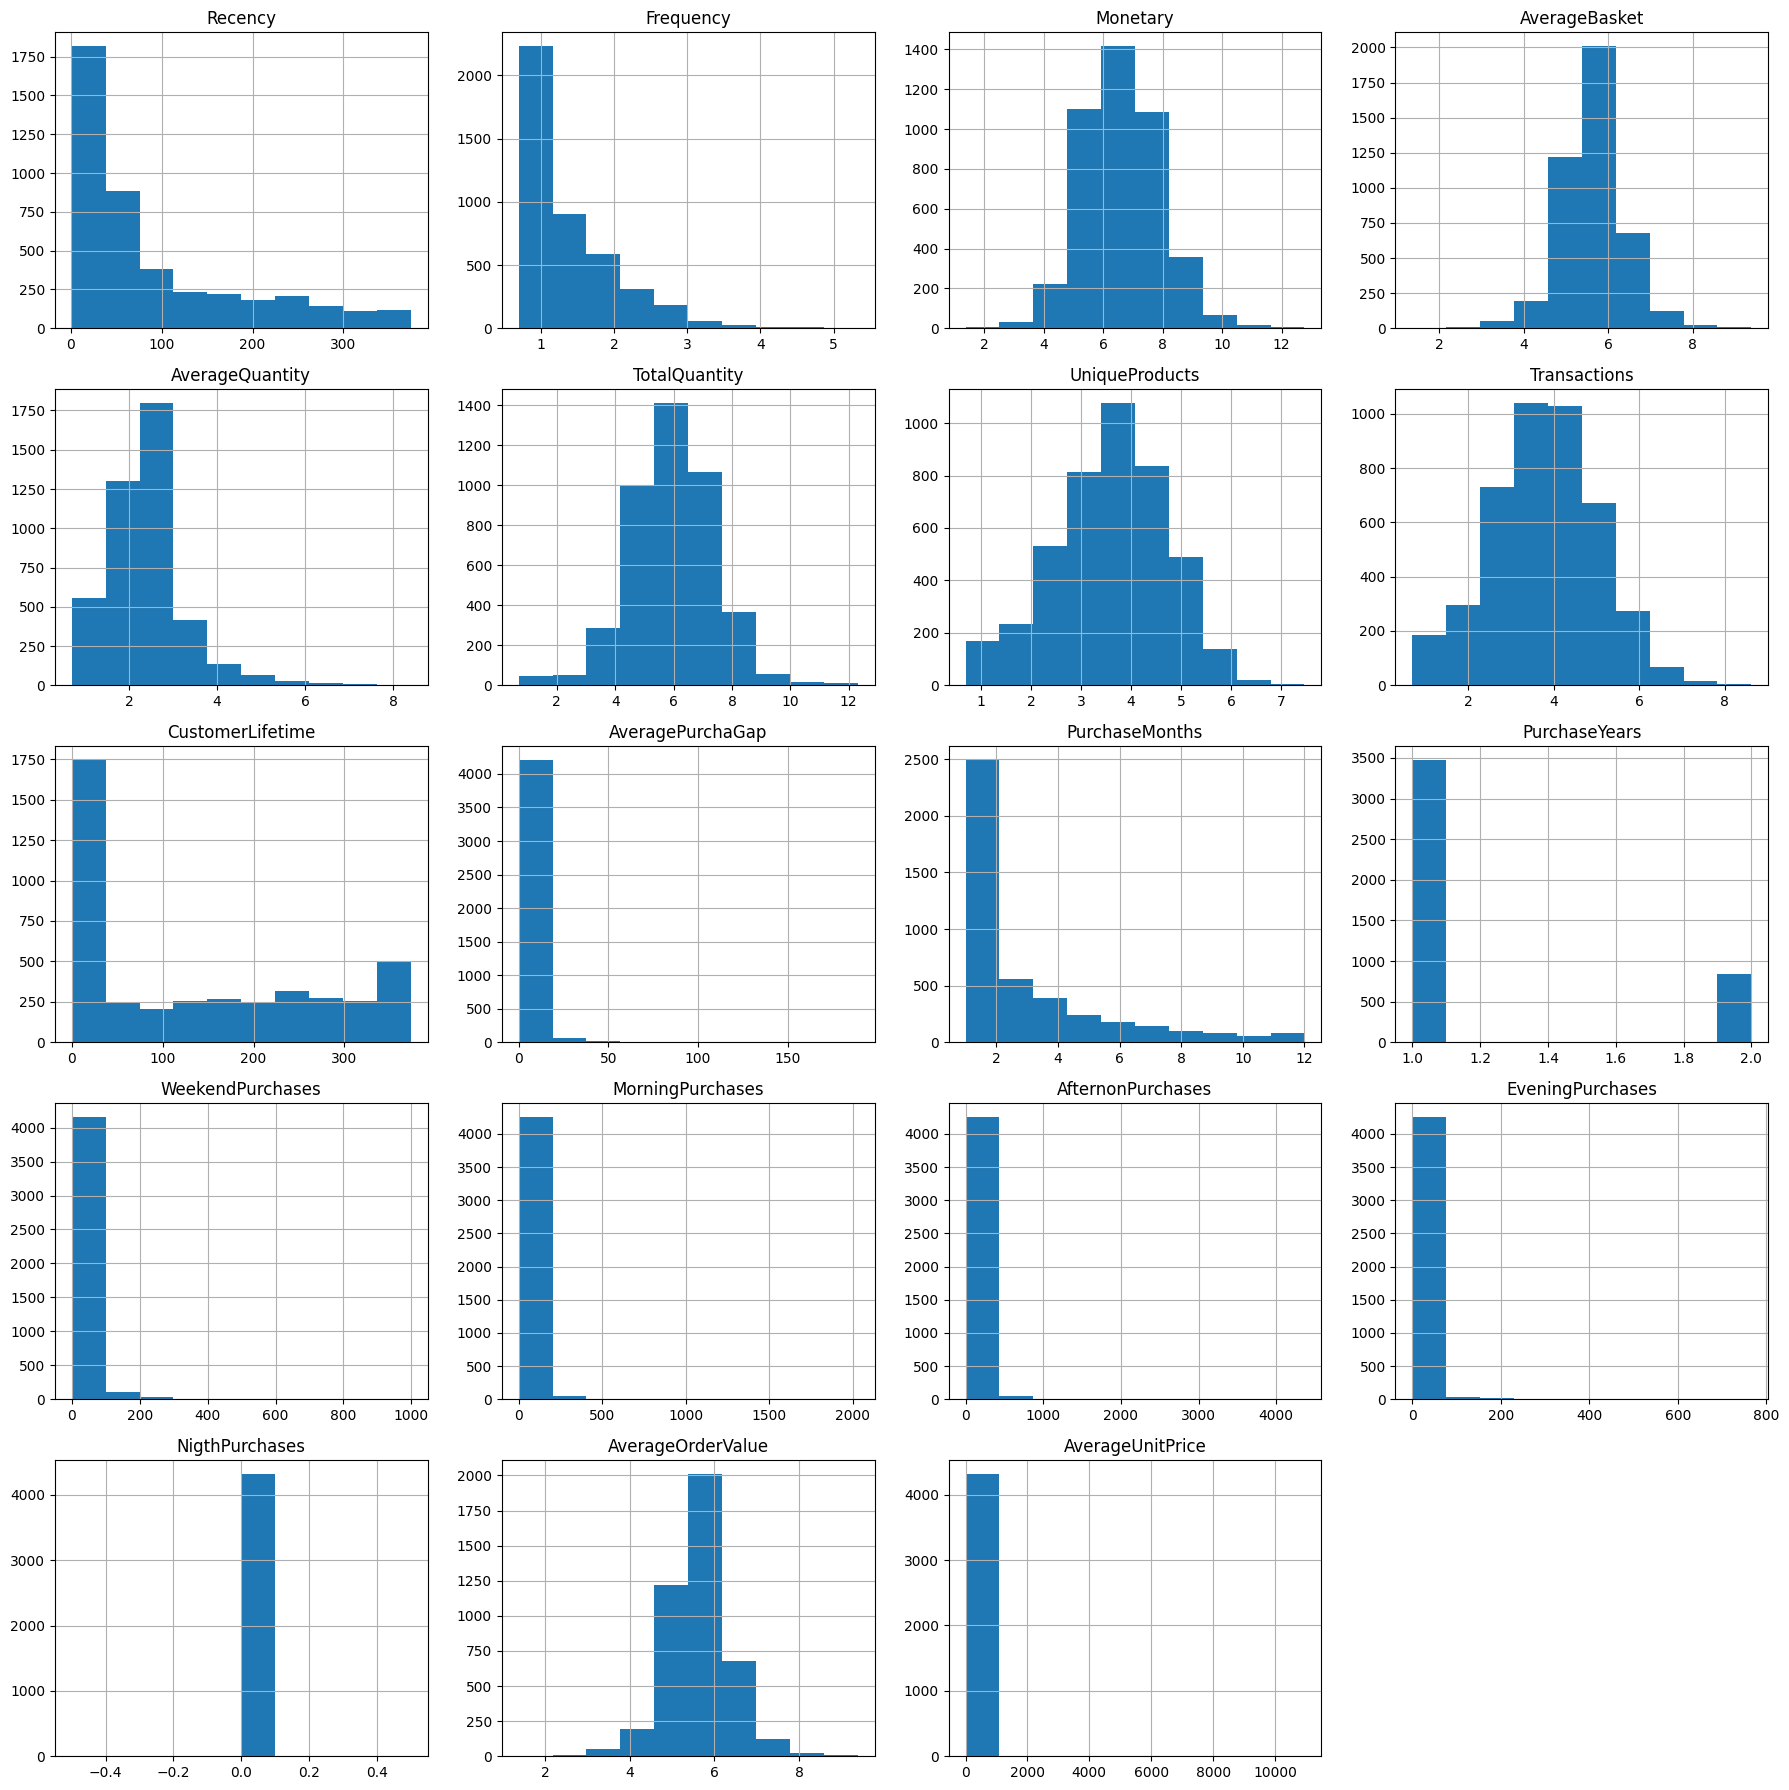

In [127]:
X.hist(figsize=(18,18))
plt.tight_layout()
plt.show()

In [128]:
skewness = X.skew()

print(skewness.sort_values(ascending=False))

Country_Brazil                  65.665821
Country_Nigeria                 65.665821
Country_Singapore               65.665821
Country_Lithuania               65.665821
Country_Canada                  65.665821
Country_RSA                     65.665821
Country_Thailand                65.665821
Country_Iceland                 65.665821
Country_Malta                   65.665821
Country_West Indies             65.665821
Country_Korea                   46.416584
Country_Israel                  46.416584
Country_Poland                  46.416584
Country_Bahrain                 46.416584
AverageUnitPrice                45.855519
Country_Unspecified             32.798617
Country_EIRE                    32.798617
Country_United Arab Emirates    32.798617
Country_Greece                  32.798617
Country_Norway                  29.325747
Country_USA                     26.761283
Country_Japan                   26.761283
Country_Cyprus                  24.767486
Country_Finland                 24

In [123]:
log_columns = [
    "Monetary",
    "Frequency",
    "AverageBasket",
    "AverageOrderValue",
    "TotalQuantity",
    "Transactions",
    "UniqueProducts",
    "AverageQuantity"
]

for col in log_columns:
    X[col] = np.log1p(X[col])

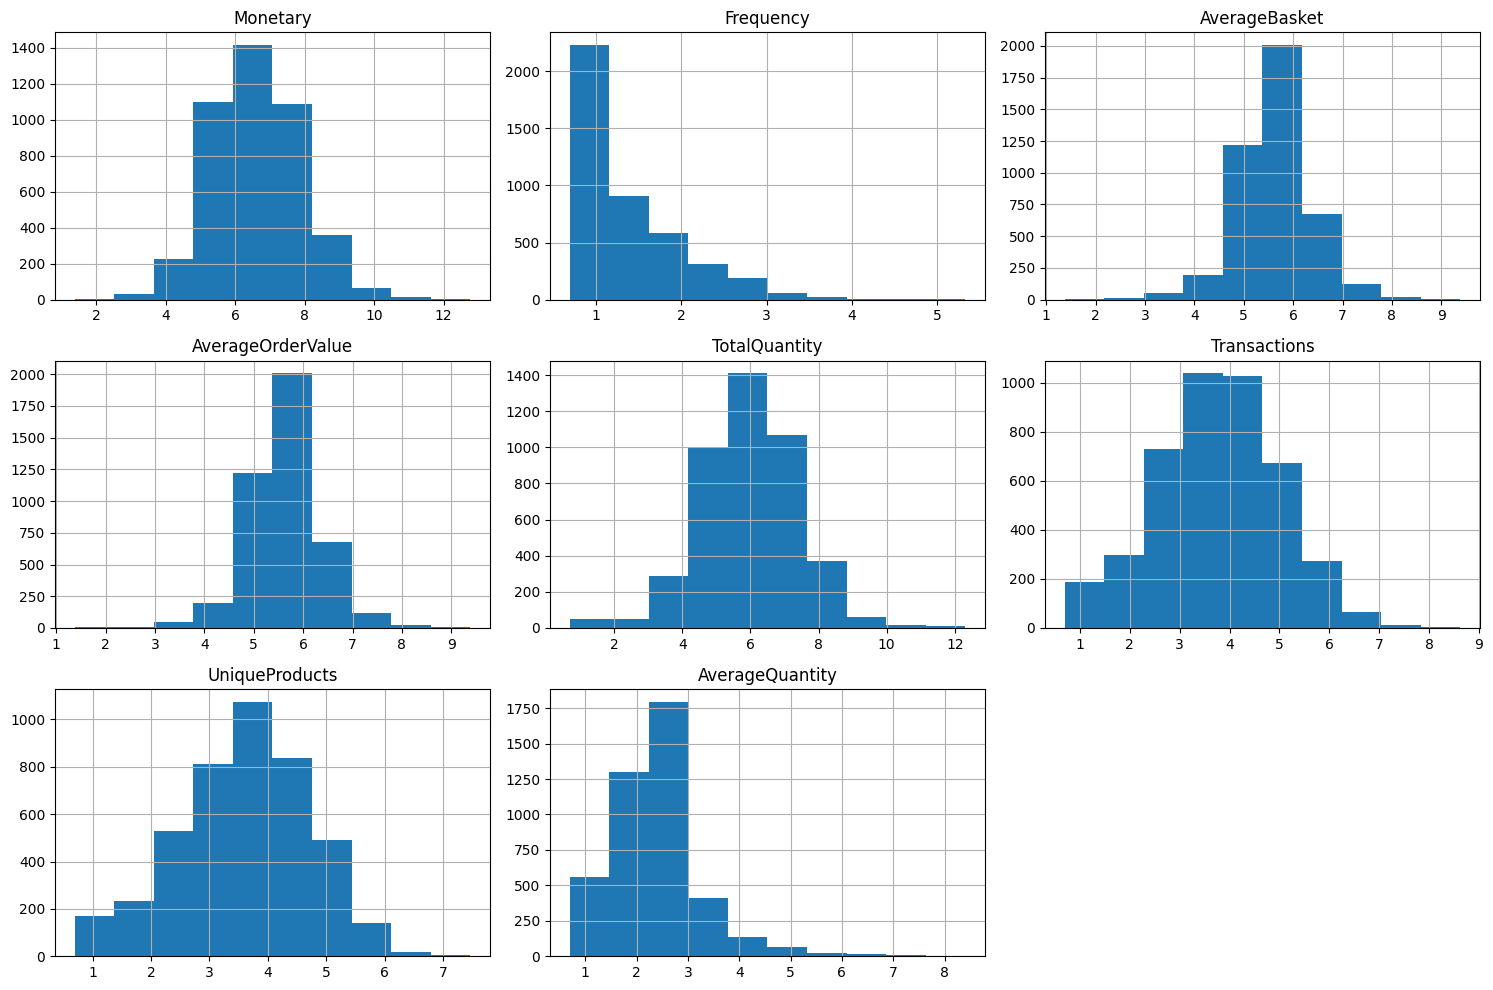

In [124]:
X[log_columns].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

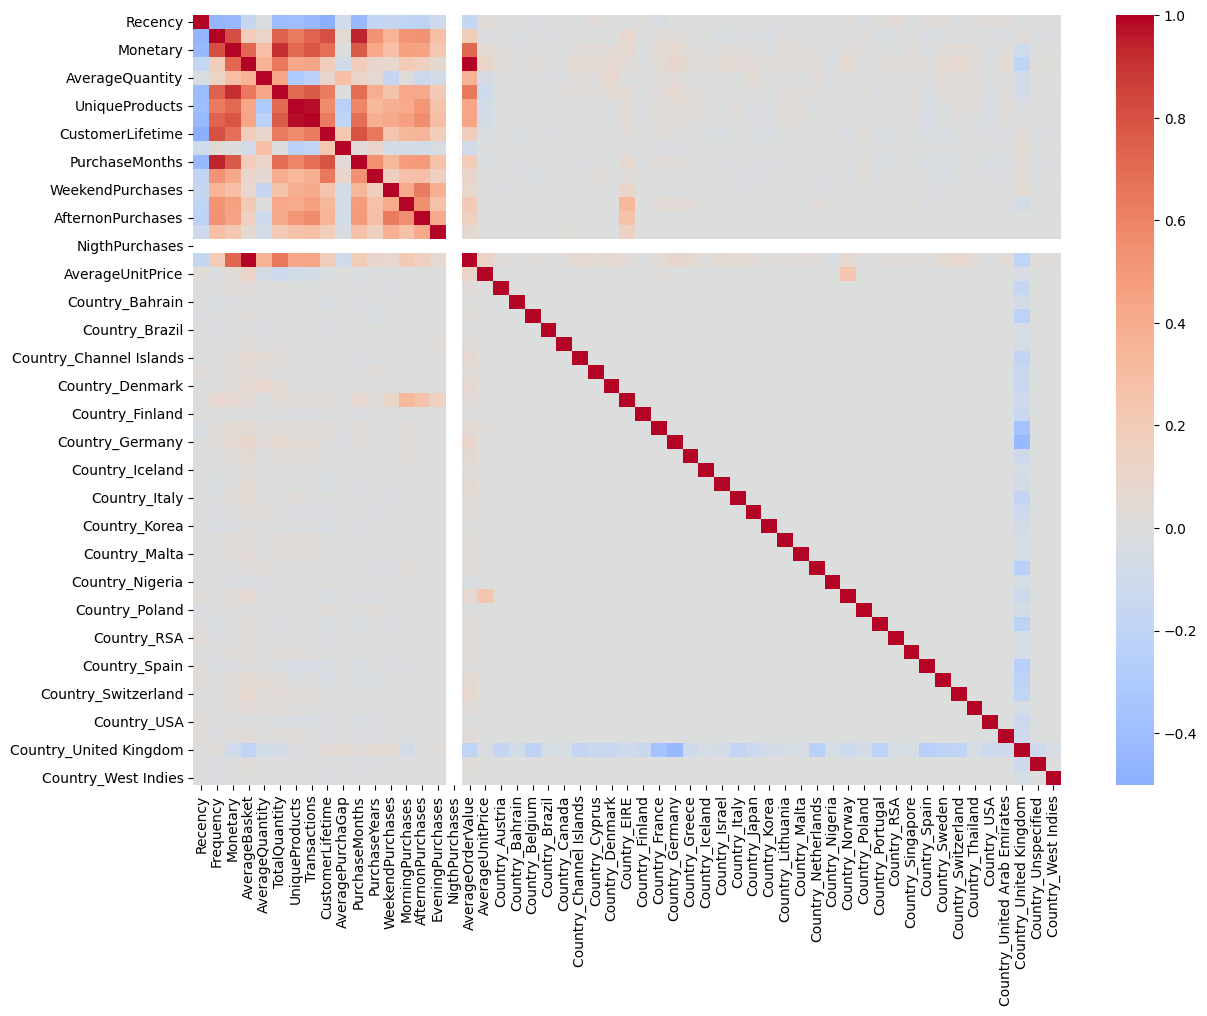

In [129]:
import seaborn as sns

plt.figure(figsize=(14,10))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0
)

plt.show()

In [130]:
corr = X.corr().abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95)
]

X = X.drop(columns=to_drop)

In [131]:
print(to_drop)

['Transactions', 'AverageOrderValue']


In [132]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [133]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

In [134]:
X_scaled.describe()

,Recency,Frequency,Monetary,AverageBasket,AverageQuantity,TotalQuantity,UniqueProducts,CustomerLifetime,AveragePurchaGap,PurchaseMonths,...,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_Thailand,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified,Country_West Indies
count,4.312000e+03,4.312000e+03,4.312000e+03,4.312000e+03,4.312000e+03,4.312000e+03,4.312000e+03,4.312000e+03,4.312000e+03,4.312000e+03,...,4.312000e+03,4.312000e+03,4.312000e+03,4.312000e+03,4.312000e+03,4.312000e+03,4.312000e+03,4.312000e+03,4.312000e+03,4.312000e+03
mean,5.602610e-17,6.385327e-17,2.306957e-16,4.020696e-16,-2.636522e-17,-3.295653e-16,3.674653e-16,8.568697e-17,2.183370e-17,-5.602610e-17,...,1.647826e-18,6.591306e-18,1.318261e-17,-1.977392e-17,3.295653e-18,3.295653e-18,-3.295653e-18,2.109218e-16,-4.943479e-18,3.295653e-18
std,1.000116e+00,1.000116e+00,1.000116e+00,1.000116e+00,1.000116e+00,1.000116e+00,1.000116e+00,1.000116e+00,1.000116e+00,1.000116e+00,...,1.000116e+00,1.000116e+00,1.000116e+00,1.000116e+00,1.000116e+00,1.000116e+00,1.000116e+00,1.000116e+00,1.000116e+00,1.000116e+00
min,-9.310522e-01,-9.819103e-01,-4.086817e+00,-5.732823e+00,-1.941296e+00,-3.660910e+00,-2.529221e+00,-1.008936e+00,-3.257427e-01,-7.999747e-01,...,-1.523039e-02,-7.481320e-02,-6.102782e-02,-5.707301e-02,-1.523039e-02,-3.732833e-02,-3.047138e-02,-3.401680e+00,-3.047138e-02,-1.523039e-02
25%,-7.555219e-01,-9.819103e-01,-6.855851e-01,-5.868556e-01,-6.201205e-01,-6.268442e-01,-6.085284e-01,-1.008936e+00,-3.257427e-01,-7.999747e-01,...,-1.523039e-02,-7.481320e-02,-6.102782e-02,-5.707301e-02,-1.523039e-02,-3.732833e-02,-3.047138e-02,2.939724e-01,-3.047138e-02,-1.523039e-02
50%,-3.941361e-01,-3.946928e-01,-4.226108e-02,3.315147e-02,-4.310947e-02,-1.034168e-02,6.735143e-02,-2.183436e-01,-2.203426e-01,-3.972320e-01,...,-1.523039e-02,-7.481320e-02,-6.102782e-02,-5.707301e-02,-1.523039e-02,-3.732833e-02,-3.047138e-02,2.939724e-01,-3.047138e-02,-1.523039e-02
75%,4.628645e-01,6.091622e-01,6.547718e-01,5.582428e-01,4.042178e-01,6.557964e-01,6.981085e-01,9.035448e-01,-2.026424e-02,4.082533e-01,...,-1.523039e-02,-7.481320e-02,-6.102782e-02,-5.707301e-02,-1.523039e-02,-3.732833e-02,-3.047138e-02,2.939724e-01,-3.047138e-02,-1.523039e-02
max,2.920288e+00,5.730367e+00,4.804321e+00,5.050732e+00,6.958326e+00,4.413266e+00,3.388426e+00,1.799550e+00,1.891940e+01,3.630195e+00,...,6.565821e+01,1.336663e+01,1.638597e+01,1.752142e+01,6.565821e+01,2.678930e+01,3.281768e+01,2.939724e-01,3.281768e+01,6.565821e+01


In [136]:
X_scaled.to_csv(
    "customer_features_scaled.csv"
)

In [137]:
print("Rows :", X_scaled.shape[0])
print("Columns :", X_scaled.shape[1])

X_scaled.head()

Rows : 4312
Columns : 53


,Recency,Frequency,Monetary,AverageBasket,AverageQuantity,TotalQuantity,UniqueProducts,CustomerLifetime,AveragePurchaGap,PurchaseMonths,...,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_Thailand,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified,Country_West Indies
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346.0,0.762299,1.613017,-0.534787,-2.799420,-1.427552,-1.178684,-0.254093,0.466837,0.285214,0.408253,...,-0.01523,-0.074813,-0.061028,-0.057073,-0.01523,-0.037328,-0.030471,0.293972,-0.030471,-0.01523
12347.0,-0.910402,-0.394693,0.452542,1.164282,0.188893,0.530271,0.591067,-0.730346,-0.271920,-0.397232,...,-0.01523,-0.074813,-0.061028,-0.057073,-0.01523,-0.037328,-0.030471,-3.401680,-0.030471,-0.01523
12348.0,-0.177305,-0.981910,-0.937590,-0.301127,0.696173,-0.023237,-0.473778,-1.008936,-0.325743,-0.799975,...,-0.01523,-0.074813,-0.061028,-0.057073,-0.01523,-0.037328,-0.030471,-3.401680,-0.030471,-0.01523
12349.0,-0.497389,0.021945,1.000535,1.563507,-0.001641,0.656496,0.808012,0.353895,-0.144270,0.005511,...,-0.01523,-0.074813,-0.061028,-0.057073,-0.01523,-0.037328,-0.030471,-3.401680,-0.030471,-0.01523
12351.0,-0.827799,-0.981910,-0.701598,0.105905,0.256744,-0.270735,-0.433113,-1.008936,-0.325743,-0.799975,...,-0.01523,-0.074813,-0.061028,-0.057073,-0.01523,-0.037328,-0.030471,-3.401680,32.817678,-0.01523


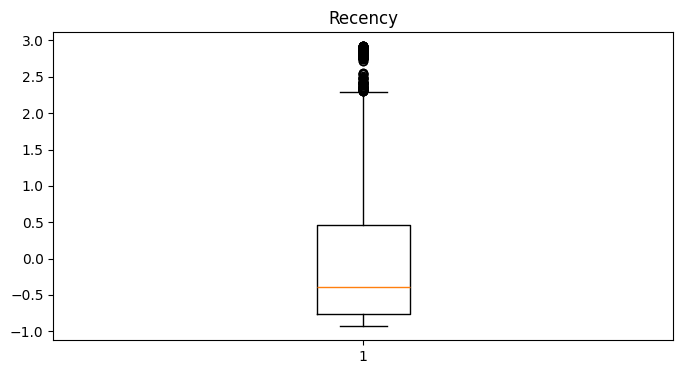

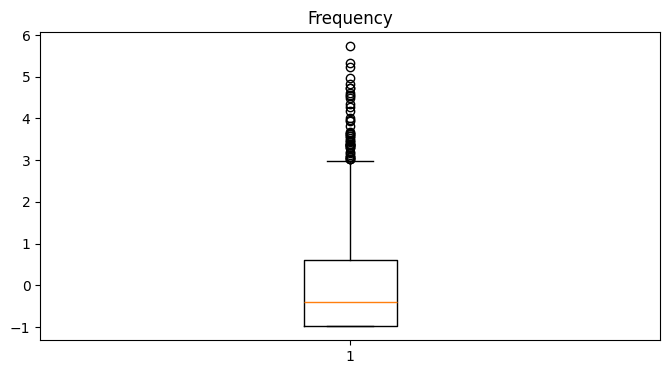

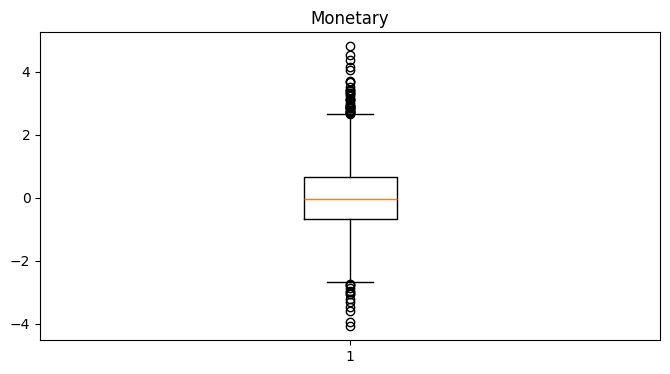

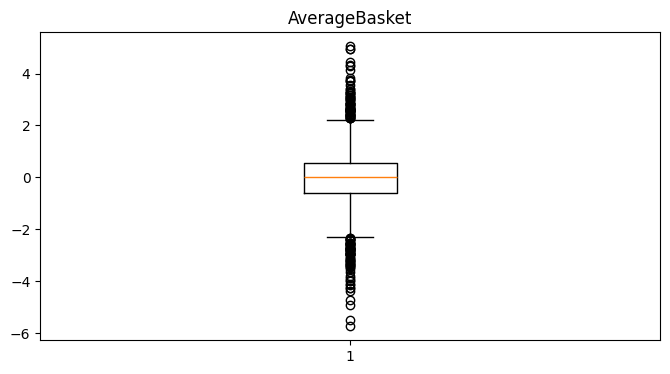

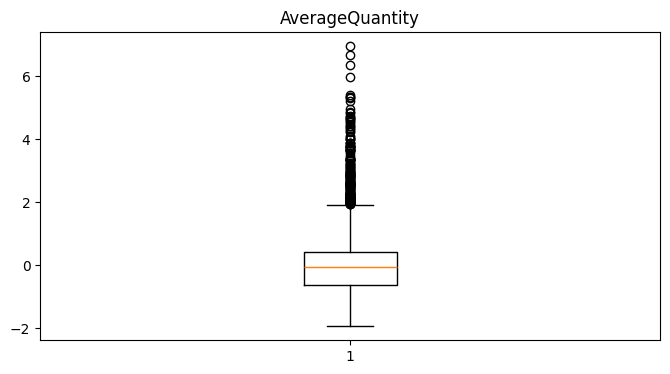

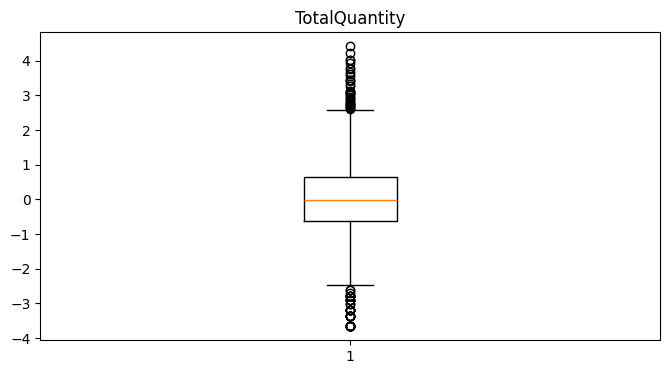

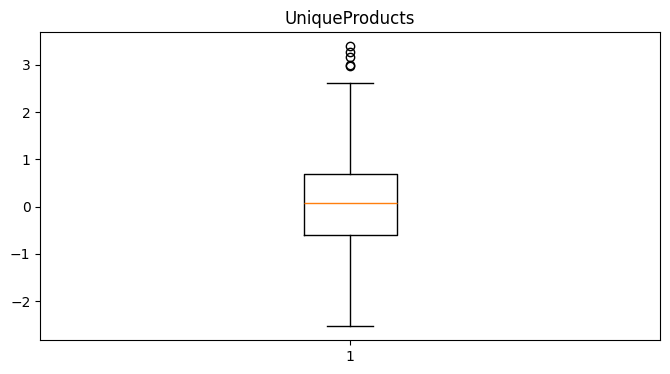

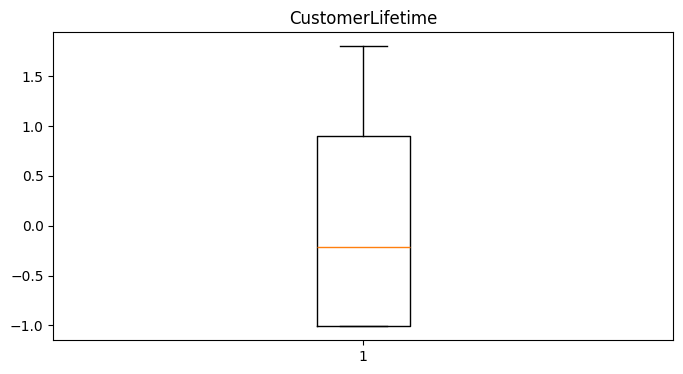

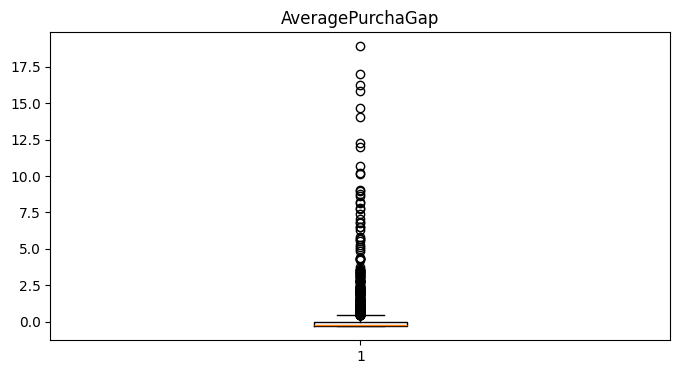

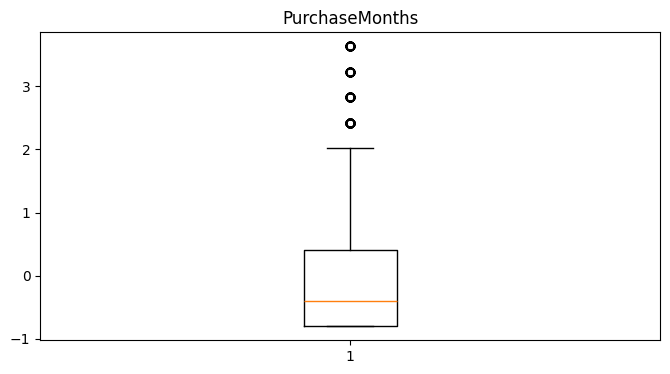

In [138]:
numeric_columns = X_scaled.columns[:10]

for column in numeric_columns:
    plt.figure(figsize=(8,4))
    plt.boxplot(X_scaled[column])
    plt.title(column)
    plt.show()

In [141]:
Q1 = X_scaled.quantile(0.25)

Q3 = X_scaled.quantile(0.75)

IQR = Q3 - Q1

outliers = (
    (X < (Q1 - 1.5 * IQR)) |(X > (Q3 + 1.5 * IQR))
)

outliers.sum().sort_values(ascending=False)

Country_Austria                 4312
Country_Belgium                 4312
Country_Brazil                  4312
Country_Bahrain                 4312
PurchaseYears                   4312
AverageUnitPrice                4312
EveningPurchases                4312
Country_Korea                   4312
Country_Japan                   4312
Country_Italy                   4312
Country_Israel                  4312
Country_Iceland                 4312
Country_Greece                  4312
Country_Germany                 4312
Country_France                  4312
Country_Finland                 4312
Country_EIRE                    4312
Country_Denmark                 4312
Country_Cyprus                  4312
Country_Channel Islands         4312
Country_Canada                  4312
Country_Netherlands             4312
Country_Nigeria                 4312
Country_Norway                  4312
Country_Poland                  4312
Country_Portugal                4312
Country_RSA                     4312
C

In [142]:
from sklearn.ensemble import IsolationForest

In [143]:
iso = IsolationForest(
    n_estimators=300,
    contamination=0.02,
    random_state=42
)

In [144]:
outlier_labels = iso.fit_predict(X_scaled)

In [145]:
import pandas as pd

pd.Series(outlier_labels).value_counts()

 1    4225
-1      87
Name: count, dtype: int64

In [146]:
X_clean = X_scaled[outlier_labels == 1]

In [147]:
customer_clean = customer_features.loc[X_clean.index]

In [148]:
print("Original:", X_scaled.shape)

print("Clean:", X_clean.shape)

print("Removed:", X_scaled.shape[0]-X_clean.shape[0])

Original: (4312, 53)
Clean: (4225, 53)
Removed: 87


In [149]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

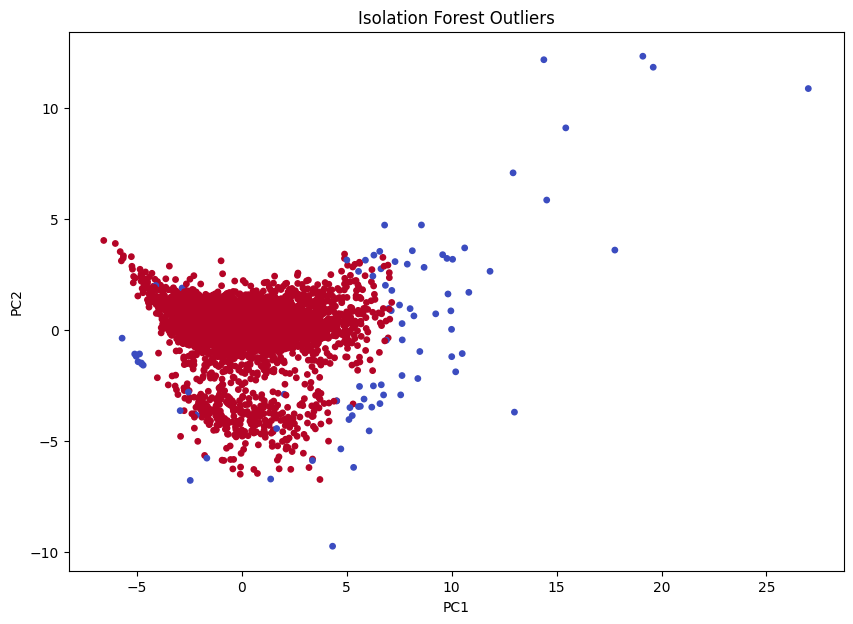

In [150]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=outlier_labels,
    cmap="coolwarm",
    s=15
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("Isolation Forest Outliers")

plt.show()

In [151]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    contamination=0.02
)

labels = lof.fit_predict(X_scaled)

In [152]:
pd.Series(labels).value_counts()

 1    4225
-1      87
Name: count, dtype: int64

In [153]:
X_clean.to_csv(
    "customer_features_clean.csv"
)

In [154]:
import joblib

joblib.dump(
    iso,
    "isolation_forest.pkl"
)

['isolation_forest.pkl']

In [155]:
summary = pd.DataFrame({
    "Original Rows": [X_scaled.shape[0]],
    "Rows After Cleaning": [X_clean.shape[0]],
    "Outliers Removed": [X_scaled.shape[0]-X_clean.shape[0]]
})

print(summary)

   Original Rows  Rows After Cleaning  Outliers Removed
0           4312                 4225                87


In [156]:
pca = PCA()

pca.fit(X_clean)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [157]:
explained_variance = pca.explained_variance_ratio_

In [158]:
print(explained_variance)

[1.13557434e-01 4.36490686e-02 3.27358375e-02 2.81568679e-02
 2.25152481e-02 2.21312473e-02 2.21272073e-02 2.21078642e-02
 2.21019349e-02 2.20973625e-02 2.20922350e-02 2.20844218e-02
 2.20765360e-02 2.20685338e-02 2.20674545e-02 2.20647380e-02
 2.20625606e-02 2.20618334e-02 2.20608482e-02 2.20605494e-02
 2.20577721e-02 2.20573063e-02 2.20566457e-02 2.20211510e-02
 2.19875234e-02 2.17329634e-02 2.12714690e-02 2.09126792e-02
 2.07513383e-02 2.05812795e-02 2.01882515e-02 1.93829376e-02
 1.89958196e-02 1.85619606e-02 1.84312201e-02 1.78187919e-02
 1.75696637e-02 1.72304690e-02 1.25995686e-02 1.15811844e-02
 1.02468994e-02 8.67334741e-03 5.59119560e-03 4.67248784e-03
 3.68371800e-03 3.50917061e-03 1.90582296e-03 1.20878454e-03
 4.39191287e-04 2.49480906e-04 1.26352087e-04 2.37710765e-05
 0.00000000e+00]


In [159]:
cumulative_variance = np.cumsum(explained_variance)

In [160]:
cumulative_variance

array([0.11355743, 0.1572065 , 0.18994234, 0.21809921, 0.24061446,
       0.2627457 , 0.28487291, 0.30698077, 0.32908271, 0.35118007,
       0.37327231, 0.39535673, 0.41743327, 0.4395018 , 0.46156925,
       0.48363399, 0.50569655, 0.52775839, 0.54981923, 0.57187978,
       0.59393756, 0.61599486, 0.63805151, 0.66007266, 0.68206018,
       0.70379315, 0.72506461, 0.74597729, 0.76672863, 0.78730991,
       0.80749816, 0.8268811 , 0.84587692, 0.86443888, 0.8828701 ,
       0.90068889, 0.91825856, 0.93548903, 0.94808859, 0.95966978,
       0.96991668, 0.97859003, 0.98418122, 0.98885371, 0.99253743,
       0.9960466 , 0.99795242, 0.9991612 , 0.9996004 , 0.99984988,
       0.99997623, 1.        , 1.        ])

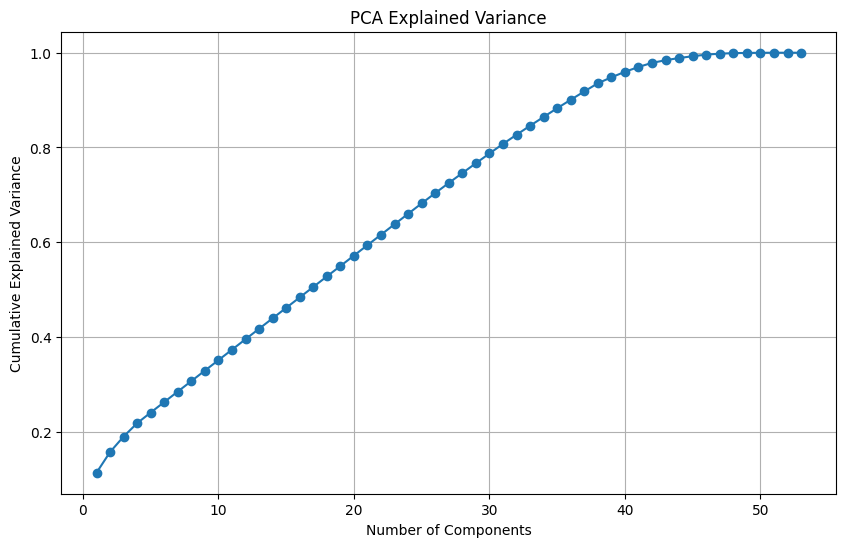

In [161]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

In [162]:
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_clean)

In [163]:
print("Original Shape :", X_clean.shape)

print("Reduced Shape :", X_pca.shape)

Original Shape : (4225, 53)
Reduced Shape : (4225, 40)


In [164]:
print(
    pca.explained_variance_ratio_.sum()
)

0.959669778264775


In [165]:
import pandas as pd

pca_columns = [
    f"PC{i+1}"
    for i in range(X_pca.shape[1])
]

X_pca = pd.DataFrame(
    X_pca,
    columns=pca_columns,
    index=X_clean.index
)

In [167]:
X_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346.0,-0.201073,2.453996,-0.414640,-2.685394,0.525297,0.004503,0.027891,0.020975,0.010519,0.023501,...,-0.266607,-0.021382,-0.371934,-0.595684,0.553225,0.516880,0.238251,1.125297,-0.446008,-0.166789
12347.0,0.607171,-5.397854,-2.417773,0.304770,-14.307637,-4.175557,2.137465,10.151142,-3.585912,-14.837753,...,-1.286607,-1.454419,-1.398274,-2.010709,1.539999,0.785819,0.214632,2.462143,-0.398832,-0.216876
12348.0,-1.608568,-4.037836,0.083975,-2.448702,-0.239797,-0.057976,0.001256,-0.046572,-0.017153,0.021280,...,0.041979,3.831967,22.888061,-7.466031,2.376121,-1.209425,0.056057,0.782881,-1.329168,-0.441042
12349.0,1.575583,-5.146588,-1.614364,-1.744177,-4.125979,3.810578,-9.126484,-5.594786,-7.969585,9.804877,...,-0.398708,-0.890011,-0.618448,-0.914148,0.434498,-0.218109,0.094637,0.403549,0.059399,-0.341078
12351.0,-1.516169,-4.645624,-1.965396,-2.353050,2.038519,-6.740400,-0.213007,6.573466,-3.380590,-4.690077,...,-0.149886,-0.526328,-0.450975,-0.281137,-0.359716,-0.845962,0.198234,-1.080094,-1.369785,0.665424


### PCA Feature Importance

In [168]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=pca_columns,
    index=X_clean.columns
)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40
Recency,-0.237601,-0.040973,-0.003744,0.142938,0.249172,-0.019191,0.001758,-0.003058,-0.003631,0.011619,...,-0.034247,-0.108910,-0.066456,-0.173845,0.236772,0.253910,-0.048461,0.606684,0.303727,-0.309331
Frequency,0.361723,0.111148,0.027115,-0.130185,0.009601,-0.016166,-0.001279,0.008332,-0.001146,0.000543,...,0.003258,-0.009146,-0.020494,0.000502,0.028046,0.005119,0.011829,0.035389,-0.184379,-0.282015
Monetary,0.382963,-0.129673,0.048190,0.179935,0.004903,-0.003676,-0.004832,-0.004314,0.004024,0.001709,...,0.013329,-0.016344,0.012381,0.014369,0.002378,0.006421,-0.020899,0.016712,0.044770,-0.009164
AverageBasket,0.208003,-0.357391,0.043172,0.477940,0.002594,0.016782,-0.005749,-0.015037,0.004470,-0.001493,...,0.018495,-0.022096,0.041855,0.018370,-0.022845,0.017330,-0.053351,0.008621,0.273478,0.307253
AverageQuantity,0.059120,-0.244132,0.635179,0.174510,0.002575,-0.007212,0.005431,0.004327,-0.009553,-0.000958,...,0.025812,-0.046677,-0.008846,0.034840,0.020906,0.037408,-0.045936,0.089626,-0.266229,-0.184375


In [169]:
loadings["PC1"]\
    .abs()\
    .sort_values(ascending=False)\
    .head(10)

Monetary             0.382963
CustomerLifetime     0.364222
TotalQuantity        0.361987
Frequency            0.361723
PurchaseMonths       0.354864
UniqueProducts       0.327183
PurchaseYears        0.240244
Recency              0.237601
AverageBasket        0.208003
AfternonPurchases    0.154060
Name: PC1, dtype: float64

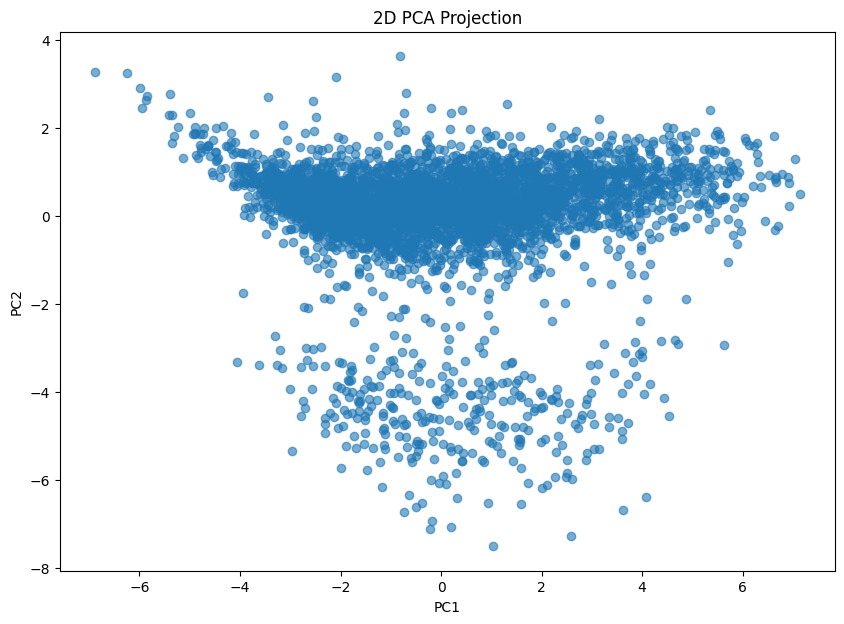

In [170]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_pca["PC1"],
    X_pca["PC2"],
    alpha=0.6
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("2D PCA Projection")

plt.show()

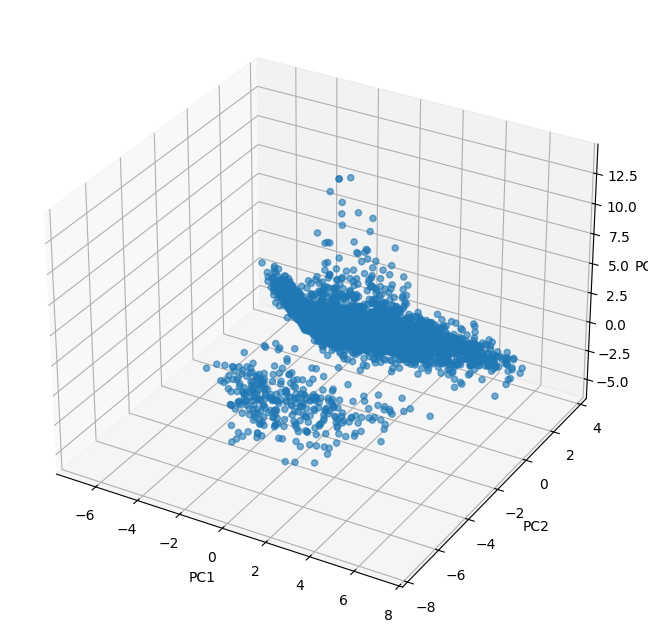

In [171]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca["PC1"],
    X_pca["PC2"],
    X_pca["PC3"],
    alpha=0.6
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()

In [172]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_clean)

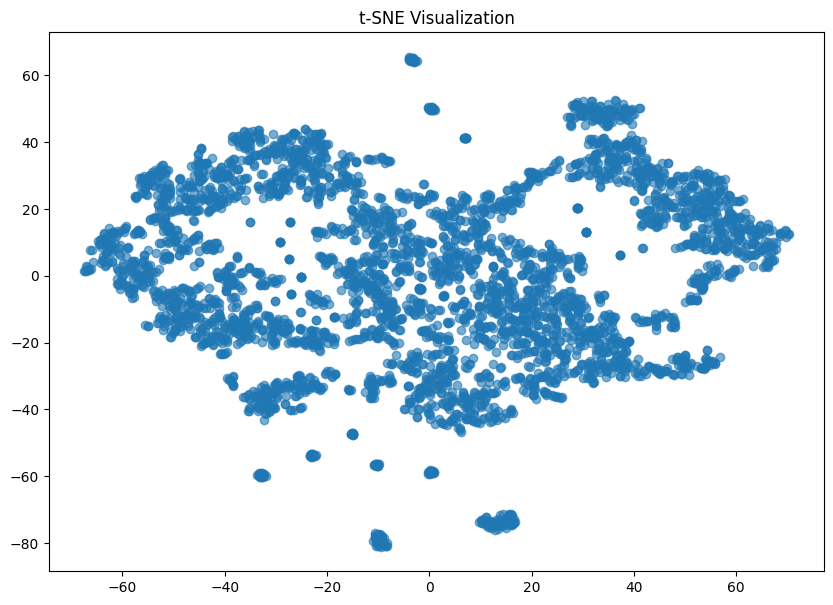

In [173]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    alpha=0.6
)

plt.title("t-SNE Visualization")

plt.show()

In [176]:
# pip install umap-learn

In [177]:
# import umap

# reducer = umap.UMAP(
#     n_neighbors=15,
#     min_dist=0.1,
#     random_state=42
# )

# X_umap = reducer.fit_transform(X_clean)

In [182]:
X_pca.to_csv(
    "customer_pca.csv"
)

In [180]:
import joblib

joblib.dump(
    pca,
    "pca.pkl"
)

['pca.pkl']

In [183]:
X_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346.0,-0.201073,2.453996,-0.414640,-2.685394,0.525297,0.004503,0.027891,0.020975,0.010519,0.023501,...,-0.266607,-0.021382,-0.371934,-0.595684,0.553225,0.516880,0.238251,1.125297,-0.446008,-0.166789
12347.0,0.607171,-5.397854,-2.417773,0.304770,-14.307637,-4.175557,2.137465,10.151142,-3.585912,-14.837753,...,-1.286607,-1.454419,-1.398274,-2.010709,1.539999,0.785819,0.214632,2.462143,-0.398832,-0.216876
12348.0,-1.608568,-4.037836,0.083975,-2.448702,-0.239797,-0.057976,0.001256,-0.046572,-0.017153,0.021280,...,0.041979,3.831967,22.888061,-7.466031,2.376121,-1.209425,0.056057,0.782881,-1.329168,-0.441042
12349.0,1.575583,-5.146588,-1.614364,-1.744177,-4.125979,3.810578,-9.126484,-5.594786,-7.969585,9.804877,...,-0.398708,-0.890011,-0.618448,-0.914148,0.434498,-0.218109,0.094637,0.403549,0.059399,-0.341078
12351.0,-1.516169,-4.645624,-1.965396,-2.353050,2.038519,-6.740400,-0.213007,6.573466,-3.380590,-4.690077,...,-0.149886,-0.526328,-0.450975,-0.281137,-0.359716,-0.845962,0.198234,-1.080094,-1.369785,0.665424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18283.0,1.188021,1.651413,-1.944549,-0.957953,-0.249567,-0.068813,0.040569,0.048994,0.007654,0.021711,...,-0.015211,0.238056,0.019392,0.047121,-0.175978,-0.392046,0.222979,-0.771900,0.175489,-0.267552
18284.0,-1.047380,-0.551373,0.336956,1.250175,-0.174815,0.038200,-0.010437,-0.008362,0.002887,-0.015559,...,0.098203,-0.006808,0.116867,0.189204,-0.178648,-0.125293,-0.118607,-0.289639,-0.191243,0.468745
18285.0,-2.249969,-0.384834,0.274581,1.188509,0.412089,0.003647,-0.002384,-0.020823,0.001522,0.013878,...,-0.021563,-0.226108,-0.069214,-0.257280,0.371632,0.463037,-0.186692,1.112535,0.478116,-0.216487


In [184]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

In [185]:
k_values = range(2, 16)

In [186]:
wcss = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X_pca)

    wcss.append(model.inertia_)

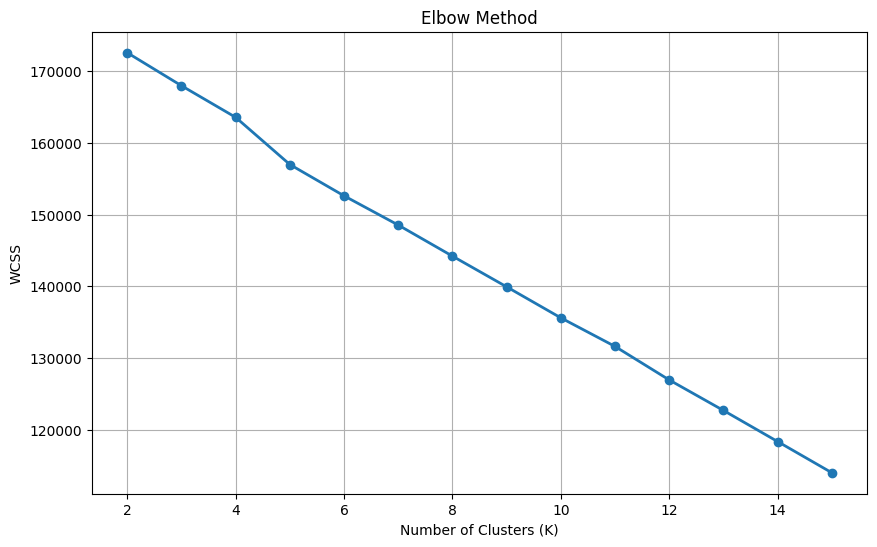

In [187]:
plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    wcss,
    marker='o',
    linewidth=2
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [188]:
silhouette_scores = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    silhouette_scores.append(score)

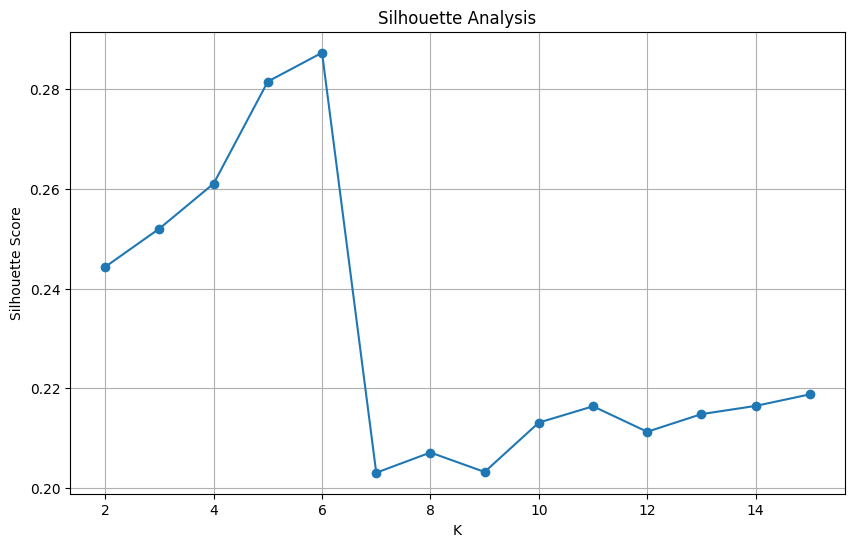

In [189]:
plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.xlabel("K")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

In [190]:
calinski_scores = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_pca)

    score = calinski_harabasz_score(
        X_pca,
        labels
    )

    calinski_scores.append(score)

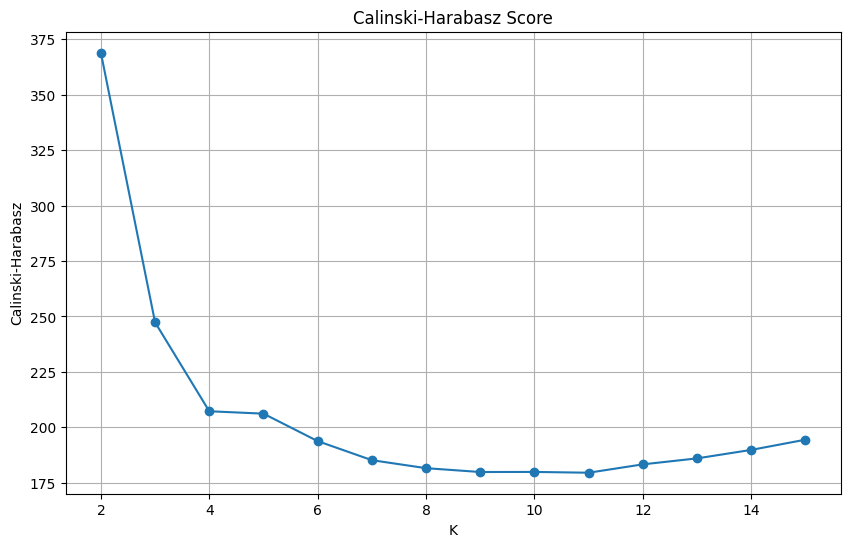

In [192]:
plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    calinski_scores,
    marker='o'
)

plt.xlabel("K")

plt.ylabel("Calinski-Harabasz")

plt.title("Calinski-Harabasz Score")

plt.grid(True)

plt.show()

In [193]:
davies_scores = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_pca)

    score = davies_bouldin_score(
        X_pca,
        labels
    )

    davies_scores.append(score)

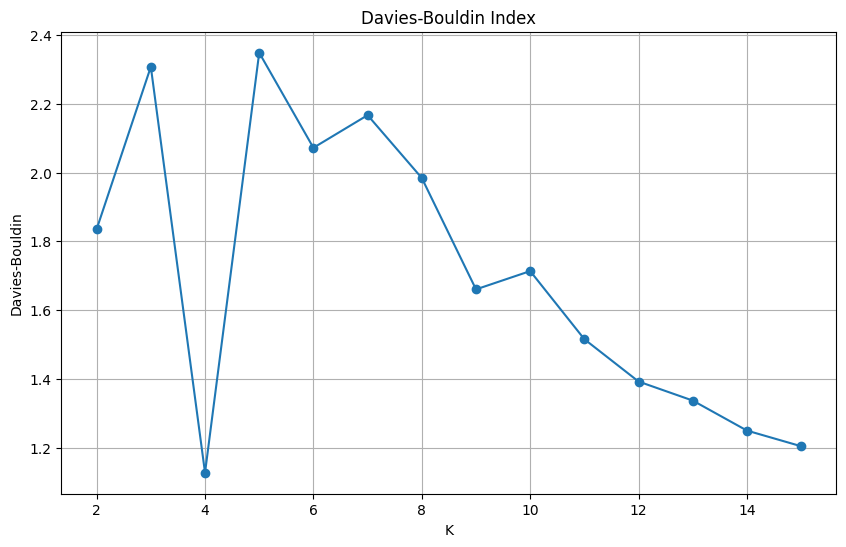

In [194]:
plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    davies_scores,
    marker='o'
)

plt.xlabel("K")

plt.ylabel("Davies-Bouldin")

plt.title("Davies-Bouldin Index")

plt.grid(True)

plt.show()

In [195]:
import pandas as pd

results = pd.DataFrame({
    "K": list(k_values),
    "WCSS": wcss,
    "Silhouette": silhouette_scores,
    "Calinski": calinski_scores,
    "Davies": davies_scores
})

results

,K,WCSS,Silhouette,Calinski,Davies
0,2,172579.272565,0.244363,368.938338,1.835246
1,3,167976.385166,0.252054,247.324043,2.307230
2,4,163566.062807,0.261074,207.225953,1.127648
3,5,156982.194961,0.281562,206.146439,2.348144
4,6,152612.551240,0.287343,193.759145,2.071942
5,7,148533.748822,0.203044,185.165652,2.166678
6,8,144198.797473,0.207102,181.556336,1.984090
7,9,139915.045086,0.203199,179.822146,1.660442
8,10,135585.545461,0.213104,179.861782,1.713605
9,11,131599.357389,0.216377,179.503581,1.515589


In [196]:
best_k_silhouette = results.loc[
    results["Silhouette"].idxmax(),
    "K"
]

print(best_k_silhouette)

6


In [197]:
best_k_calinski = results.loc[
    results["Calinski"].idxmax(),
    "K"
]

print(best_k_calinski)

2


In [198]:
best_k_davies = results.loc[
    results["Davies"].idxmin(),
    "K"
]

print(best_k_davies)

4


In [231]:
optimal_k = 2

# Train Final KMeans

In [232]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans.fit_predict(X_pca)

In [233]:
customer_clean["Cluster"] = cluster_labels

In [234]:
customer_clean["Cluster"].value_counts().sort_index()

Cluster
0    1756
1    2469
Name: count, dtype: int64

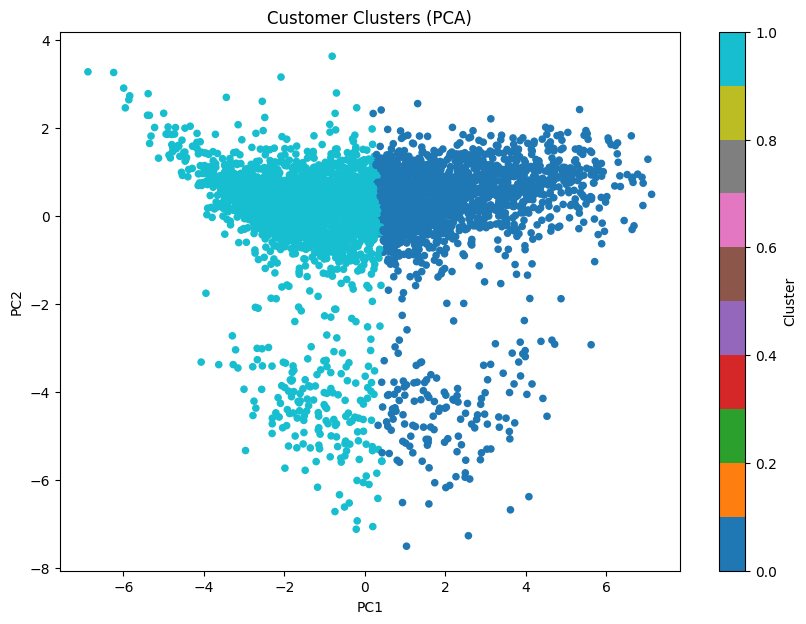

In [235]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_pca["PC1"],
    X_pca["PC2"],
    c=cluster_labels,
    cmap="tab10",
    s=20
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Clusters (PCA)")

plt.colorbar(scatter, label="Cluster")

plt.show()

In [236]:
customer_clean.to_csv(
    "customer_clustered.csv"
)

In [238]:
customer_clean.to_csv(
    "customer_clustered.csv"
)

# advance improvement

In [243]:
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN,
    Birch,
    SpectralClustering
)

from sklearn.mixture import GaussianMixture

import hdbscan

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

import pandas as pd

In [242]:
# !pip install hdbscan

In [244]:
models = {

    "KMeans":
        KMeans(
            n_clusters=4,
            random_state=42,
            n_init=20
        ),

    "Agglomerative":
        AgglomerativeClustering(
            n_clusters=4
        ),

    "GaussianMixture":
        GaussianMixture(
            n_components=4,
            random_state=42
        ),

    "DBSCAN":
        DBSCAN(
            eps=1.2,
            min_samples=10
        ),

    "HDBSCAN":
        hdbscan.HDBSCAN(
            min_cluster_size=30
        ),

    "Birch":
        Birch(
            n_clusters=4
        ),

    "Spectral":
        SpectralClustering(
            n_clusters=4,
            random_state=42
        )
}

In [245]:
def evaluate_model(model, X):

    if isinstance(model, GaussianMixture):

        labels = model.fit_predict(X)

    else:

        labels = model.fit_predict(X)

    n_clusters = len(set(labels))

    if -1 in labels:
        n_clusters -= 1

    if n_clusters < 2:
        return None

    silhouette = silhouette_score(X, labels)

    calinski = calinski_harabasz_score(X, labels)

    davies = davies_bouldin_score(X, labels)

    return {
        "Clusters": n_clusters,
        "Silhouette": silhouette,
        "Calinski": calinski,
        "Davies": davies
    }

In [246]:
results = []

cluster_predictions = {}

for name, model in models.items():

    print(f"Running {name}...")

    result = evaluate_model(model, X_pca)

    if result:

        result["Algorithm"] = name

        results.append(result)

        if isinstance(model, GaussianMixture):
            labels = model.predict(X_pca)
        else:
            labels = model.fit_predict(X_pca)

        cluster_predictions[name] = labels

Running KMeans...
Running Agglomerative...
Running GaussianMixture...
Running DBSCAN...
Running HDBSCAN...
Running Birch...
Running Spectral...


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [247]:
comparison = pd.DataFrame(results)

comparison

,Clusters,Silhouette,Calinski,Davies,Algorithm
0,4,0.261074,207.225953,1.127648,KMeans
1,4,0.238860,212.524139,3.397121,Agglomerative
2,4,0.183801,158.353304,1.370635,GaussianMixture
3,3,0.174263,106.695914,3.732523,DBSCAN
4,4,0.226557,117.077025,3.291345,HDBSCAN
5,4,0.705124,134.437269,2.396714,Birch
6,4,0.807268,97.824711,0.174601,Spectral


In [248]:
comparison = comparison.sort_values(
    "Silhouette",
    ascending=False
)

comparison

,Clusters,Silhouette,Calinski,Davies,Algorithm
6,4,0.807268,97.824711,0.174601,Spectral
5,4,0.705124,134.437269,2.396714,Birch
0,4,0.261074,207.225953,1.127648,KMeans
1,4,0.238860,212.524139,3.397121,Agglomerative
4,4,0.226557,117.077025,3.291345,HDBSCAN
2,4,0.183801,158.353304,1.370635,GaussianMixture
3,3,0.174263,106.695914,3.732523,DBSCAN


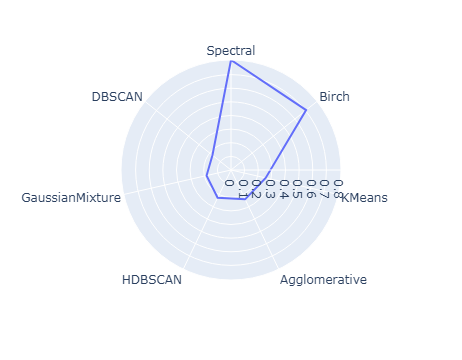

In [249]:
import plotly.express as px

fig = px.line_polar(
    comparison,
    r="Silhouette",
    theta="Algorithm",
    line_close=True
)

fig.show()

In [250]:
for name, labels in cluster_predictions.items():

    print("\n", name)

    print(pd.Series(labels).value_counts())


 KMeans
1    2412
0    1738
3      61
2      14
Name: count, dtype: int64

 Agglomerative
3    1997
2    1931
1     268
0      29
Name: count, dtype: int64

 GaussianMixture
3    2403
0    1759
1      61
2       2
Name: count, dtype: int64

 DBSCAN
 0    3004
 1     653
-1     561
 2       7
Name: count, dtype: int64

 HDBSCAN
 3    2862
-1     716
 2     548
 1      61
 0      38
Name: count, dtype: int64

 Birch
3    3928
0     294
1       2
2       1
Name: count, dtype: int64

 Spectral
0    4217
2       4
1       2
3       2
Name: count, dtype: int64


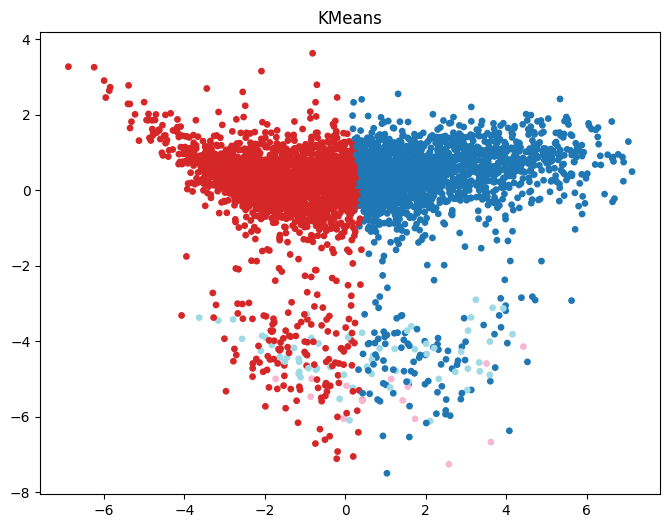

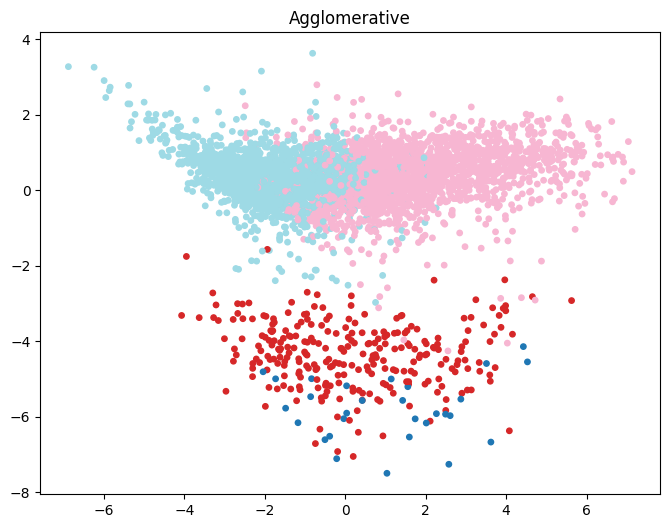

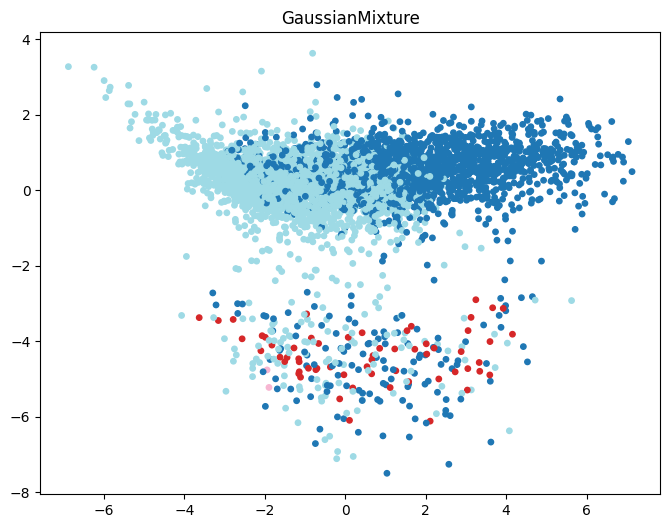

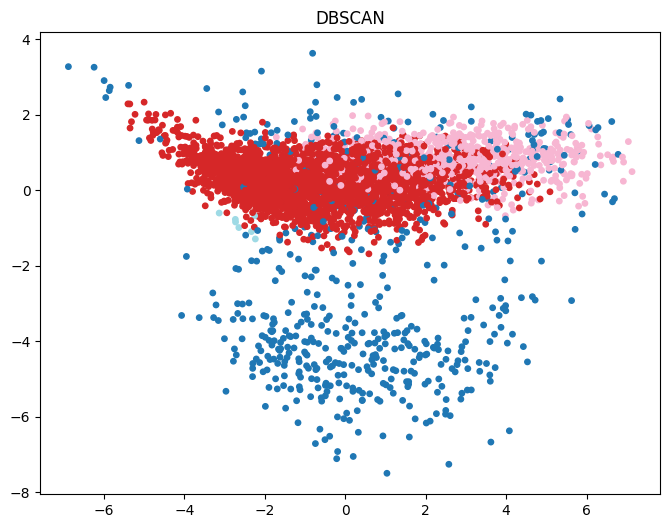

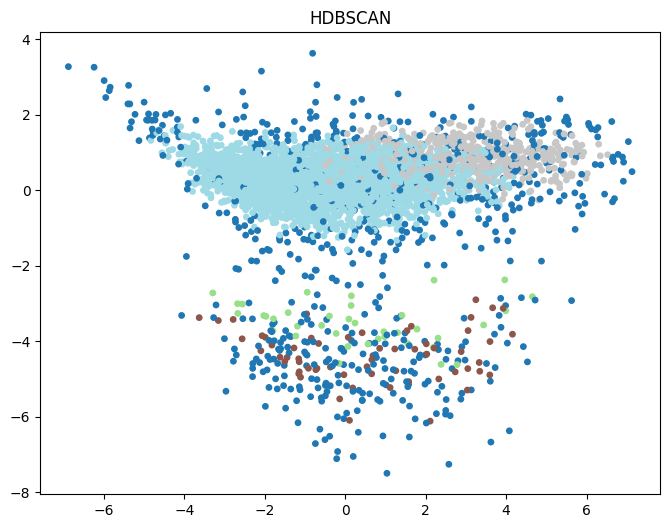

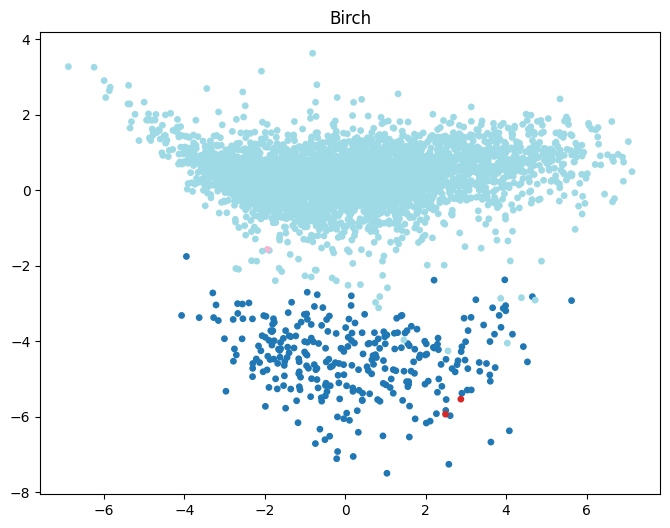

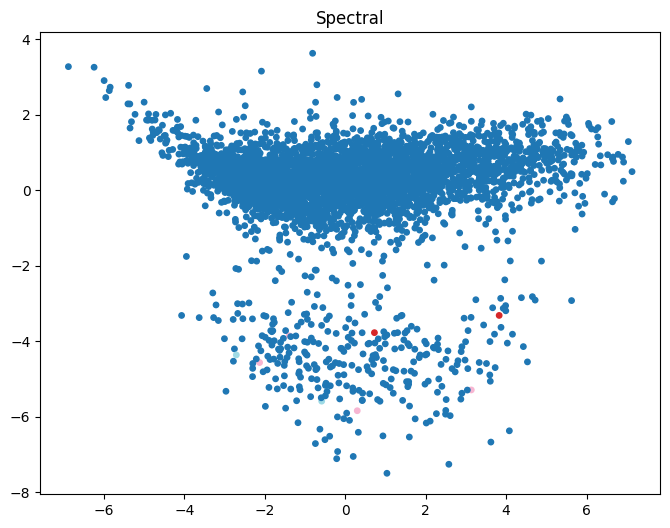

In [251]:
import matplotlib.pyplot as plt

for name, labels in cluster_predictions.items():

    plt.figure(figsize=(8,6))

    plt.scatter(
        X_pca["PC1"],
        X_pca["PC2"],
        c=labels,
        cmap="tab20",
        s=15
    )

    plt.title(name)

    plt.show()

In [252]:
from sklearn.metrics import adjusted_rand_score

In [253]:
scores = []

for seed in range(10):

    model = KMeans(
        n_clusters=4,
        random_state=seed,
        n_init=20
    )

    labels = model.fit_predict(X_pca)

    scores.append(labels)

In [254]:
for i in range(len(scores)-1):

    ari = adjusted_rand_score(
        scores[i],
        scores[i+1]
    )

    print(ari)

0.32754808213824976
0.327875082985948
0.333940405628685
0.30454051025484496
0.40218776230339237
0.34004647572457386
0.33974167951804884
0.8867704208670721
0.3238913895312822


In [255]:
customer_clean["Cluster"] = cluster_labels

In [256]:
customer_clean.head()

,Recency,Frequency,Monetary,AverageBasket,AverageQuantity,TotalQuantity,UniqueProducts,Transactions,CustomerLifetime,AveragePurchaGap,...,PurchaseYears,WeekendPurchases,MorningPurchases,AfternonPurchases,EveningPurchases,NigthPurchases,AverageOrderValue,AverageUnitPrice,Country,Cluster
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346.0,165,11,372.86,33.896364,2.121212,70,26,33,196,6.000000,...,2,0,7.0,26.0,0.0,0.0,33.896364,6.253333,United Kingdom,1
12347.0,3,2,1323.32,661.660000,11.661972,828,70,71,37,0.528571,...,1,40,0.0,71.0,0.0,0.0,661.660000,2.295070,Iceland,0
12348.0,74,1,222.16,222.160000,18.650000,373,20,20,0,0.000000,...,1,0,0.0,20.0,0.0,0.0,222.160000,0.719500,Finland,1
12349.0,43,3,2671.14,890.380000,9.735294,993,90,102,181,1.782178,...,1,0,56.0,46.0,0.0,0.0,890.380000,8.581765,Italy,0
12351.0,11,1,300.93,300.930000,12.428571,261,21,21,0,0.000000,...,1,0,0.0,21.0,0.0,0.0,300.930000,2.355238,Unspecified,1


In [259]:
cluster_counts = (
    customer_clean)

In [260]:
cluster_counts

,Recency,Frequency,Monetary,AverageBasket,AverageQuantity,TotalQuantity,UniqueProducts,Transactions,CustomerLifetime,AveragePurchaGap,...,PurchaseYears,WeekendPurchases,MorningPurchases,AfternonPurchases,EveningPurchases,NigthPurchases,AverageOrderValue,AverageUnitPrice,Country,Cluster
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346.0,165,11,372.86,33.896364,2.121212,70,26,33,196,6.000000,...,2,0,7.0,26.0,0.0,0.0,33.896364,6.253333,United Kingdom,1
12347.0,3,2,1323.32,661.660000,11.661972,828,70,71,37,0.528571,...,1,40,0.0,71.0,0.0,0.0,661.660000,2.295070,Iceland,0
12348.0,74,1,222.16,222.160000,18.650000,373,20,20,0,0.000000,...,1,0,0.0,20.0,0.0,0.0,222.160000,0.719500,Finland,1
12349.0,43,3,2671.14,890.380000,9.735294,993,90,102,181,1.782178,...,1,0,56.0,46.0,0.0,0.0,890.380000,8.581765,Italy,0
12351.0,11,1,300.93,300.930000,12.428571,261,21,21,0,0.000000,...,1,0,0.0,21.0,0.0,0.0,300.930000,2.355238,Unspecified,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18283.0,18,6,619.37,103.228333,1.483871,322,158,217,275,1.263889,...,1,55,0.0,177.0,40.0,0.0,103.228333,2.199401,United Kingdom,0
18284.0,67,1,461.68,461.680000,17.642857,494,28,28,0,0.000000,...,1,0,28.0,0.0,0.0,0.0,461.680000,3.253214,United Kingdom,1
18285.0,296,1,427.00,427.000000,12.083333,145,12,12,0,0.000000,...,1,0,12.0,0.0,0.0,0.0,427.000000,8.350000,United Kingdom,1


In [262]:
df_clustered = df.merge(
    customer_clean[["Cluster"]],
    left_on="Customer ID",
    right_index=True,
    how="inner"
)

df_clustered.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,Day,Weekday,Hours,Weekend,PurchasePeriod,Cluster
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,Tuesday,7,0,Morning,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday,7,0,Morning,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday,7,0,Morning,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,Tuesday,7,0,Morning,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,Tuesday,7,0,Morning,0


In [263]:
top_products = (
    df_clustered
    .groupby(["Cluster", "Description"])["Quantity"]
    .sum()
    .reset_index()
)

top_products = (
    top_products
    .sort_values(
        ["Cluster", "Quantity"],
        ascending=[True, False]
    )
)

top_products.head()

,Cluster,Description,Quantity
4130,0,WHITE HANGING HEART T-LIGHT HOLDER,38354
4231,0,WORLD WAR 2 GLIDERS ASSTD DESIGNS,28797
2539,0,PACK OF 72 RETRO SPOT CAKE CASES,27155
137,0,60 TEATIME FAIRY CAKE CASES,23934
252,0,ASSORTED COLOUR BIRD ORNAMENT,22767


In [264]:
top10 = (
    top_products
    .groupby("Cluster")
    .head(10)
)

top10

,Cluster,Description,Quantity
4130,0,WHITE HANGING HEART T-LIGHT HOLDER,38354
4231,0,WORLD WAR 2 GLIDERS ASSTD DESIGNS,28797
2539,0,PACK OF 72 RETRO SPOT CAKE CASES,27155
137,0,60 TEATIME FAIRY CAKE CASES,23934
252,0,ASSORTED COLOUR BIRD ORNAMENT,22767
668,0,BROCADE RING PURSE,21473
2520,0,PACK OF 12 SUKI TISSUES,20174
2516,0,PACK OF 12 RED SPOTTY TISSUES,19833
2541,0,PACK OF 72 SKULL CAKE CASES,19502
2537,0,PACK OF 60 PINK PAISLEY CAKE CASES,19462


In [265]:
def recommend_products(cluster_id, top_n=5):

    recommendations = (
        top_products[
            top_products["Cluster"] == cluster_id
        ]
        .head(top_n)
    )

    return recommendations[["Description", "Quantity"]]

In [270]:
recommend_products(1)

,Description,Quantity
8015,WHITE HANGING HEART T-LIGHT HOLDER,5427
6566,PACK OF 72 RETRO SPOT CAKE CASES,3897
4539,ASSORTED COLOUR BIRD ORNAMENT,3849
8109,WORLD WAR 2 GLIDERS ASSTD DESIGNS,3827
5959,HANGING JAM JAR T-LIGHT HOLDER,3602
